<a href="https://colab.research.google.com/github/RithvikReddy0-0/ml_lab/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# --- 1. SETUP ---
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Use the EXACT project path from your video
project_path = '/content/drive/MyDrive/GenomeDetector'
natural_data_path = os.path.join(project_path, 'data', 'natural')

# The -p flag ensures it doesn't complain if the folder already exists
!mkdir -p {natural_data_path}

print(f"Project directory is set to: {project_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory is set to: /content/drive/MyDrive/GenomeDetector


In [5]:
# --- 2. DOWNLOAD & UNZIP ---

# Install the necessary NCBI tools
!pip install ncbi-datasets-pylib > /dev/null

# Define the full path for the zip file
zip_file_path = os.path.join(natural_data_path, 'rickettsiales.zip')

# --- Download the Natural Data (Rickettsiales) ---
print("Downloading 'Natural' dataset...")
# Only download if the file doesn't already exist
if not os.path.exists(zip_file_path):
    !datasets download genome taxon "Rickettsiales" --reference --assembly-level complete --filename "{zip_file_path}"
else:
    print("Zip file already exists. Skipping download.")

# --- THIS IS THE MOST IMPORTANT STEP ---
# Unzip the file into the 'natural' directory. The '-o' flag overwrites if needed.
print("\nUnzipping the dataset... this is essential!")
!unzip -o "{zip_file_path}" -d "{natural_data_path}/"
print("Unzip complete.")

# --- Verify that it worked ---
print("\nVerifying contents:")
!ls -lR "{natural_data_path}"

Zip file already exists. Skipping download.

Unzipping the dataset... this is essential!
Archive:  /content/drive/MyDrive/GenomeDetector/data/natural/rickettsiales.zip
  inflating: /content/drive/MyDrive/GenomeDetector/data/natural/README.md  
  inflating: /content/drive/MyDrive/GenomeDetector/data/natural/ncbi_dataset/data/assembly_data_report.jsonl  
  inflating: /content/drive/MyDrive/GenomeDetector/data/natural/ncbi_dataset/data/GCF_000007025.1/GCF_000007025.1_ASM702v1_genomic.fna  
  inflating: /content/drive/MyDrive/GenomeDetector/data/natural/ncbi_dataset/data/GCF_000008045.1/GCF_000008045.1_ASM804v1_genomic.fna  
  inflating: /content/drive/MyDrive/GenomeDetector/data/natural/ncbi_dataset/data/GCF_000008385.1/GCF_000008385.1_ASM838v1_genomic.fna  
  inflating: /content/drive/MyDrive/GenomeDetector/data/natural/ncbi_dataset/data/GCF_000012385.1/GCF_000012385.1_ASM1238v1_genomic.fna  
  inflating: /content/drive/MyDrive/GenomeDetector/data/natural/ncbi_dataset/data/GCF_000012565.

In [6]:
# --- Cell 3 (Final Version with Typo Fixed) ---
!pip install biopython

import numpy as np
from itertools import product
from Bio import SeqIO
import glob
import os

# ---- Modularized Functions ----

def get_kmer_features(k):
    """Generates all possible k-mers for a given k."""
    letters = ['A', 'C', 'G', 'T']
    return sorted([''.join(p) for p in product(letters, repeat=k)])

def sequence_to_kmer_counts(sequence, k, kmer_features):
    """Converts a DNA sequence into a vector of k-mer counts."""
    kmer_counts = {kmer: 0 for kmer in kmer_features}
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k].upper()
        if kmer in kmer_counts:
            kmer_counts[kmer] += 1
    return list(kmer_counts.values())

def load_and_process_genera(natural_path, k):
    """
    Loads natural genomes and creates a two-class problem by separating two genera.
    Class 0: Rickettsia
    Class 1: Wolbachia
    """
    X, y = [], []
    kmer_features = get_kmer_features(k)

    # This is the search path that finds the unzipped files
    search_pattern = os.path.join(natural_path, "ncbi_dataset", "data", "**", "*.fna")
    natural_files = glob.glob(search_pattern, recursive=True)

    # --- THIS IS THE CORRECTED LINE ---
    # The variable now correctly uses one underscore.
    if not natural_files:
        print("ERROR: No .fna files found. Please check the output of Cell 2.")
        return np.array(X), np.array(y)

    for filepath in natural_files:
        for record in SeqIO.parse(filepath, "fasta"):
            organism_name = record.description.lower()
            if len(record.seq) < 1000: continue

            label = -1
            if "rickettsia" in organism_name: label = 0
            elif "wolbachia" in organism_name: label = 1

            if label != -1:
                X.append(sequence_to_kmer_counts(str(record.seq), k, kmer_features))
                y.append(label)

    return np.array(X), np.array(y)

# --- Main Program Logic ---

K_VALUE = 4
# Use the correct path for your project
natural_data_path = '/content/drive/MyDrive/GenomeDetector/data/natural'

print(f"\nProcessing data using k={K_VALUE}...")
X, y = load_and_process_genera(natural_data_path, K_VALUE)

print(f"Data processing complete.")
print(f"Shape of our feature matrix X: {X.shape}")
print(f"Shape of our label vector y: {y.shape}")
print(f"Number of Rickettsia samples (class 0): {np.sum(y == 0)}")
print(f"Number of Wolbachia samples (class 1): {np.sum(y == 1)}")


Processing data using k=4...
Data processing complete.
Shape of our feature matrix X: (274, 256)
Shape of our label vector y: (274,)
Number of Rickettsia samples (class 0): 39
Number of Wolbachia samples (class 1): 235



--- A1: Class Centroids and Spread ---
Average Spread (Intra-class) for Rickettsia (Class 0): 2283.9572
Average Spread (Intra-class) for Wolbachia (Class 1): 1086.7020
Distance between Centroids (Inter-class distance): 19413.5805

--- A2: Feature Histogram ---


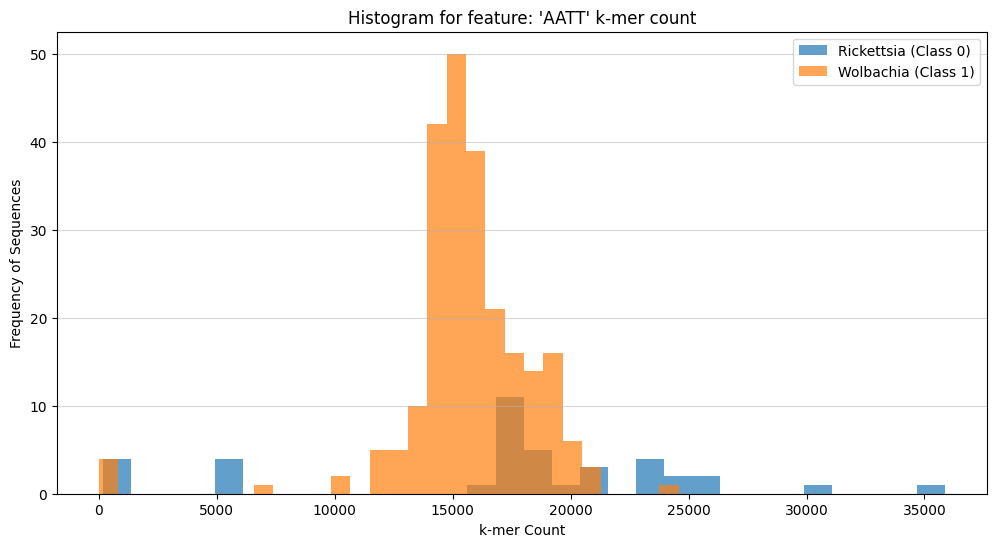


--- A3: Minkowski Distance Plot ---


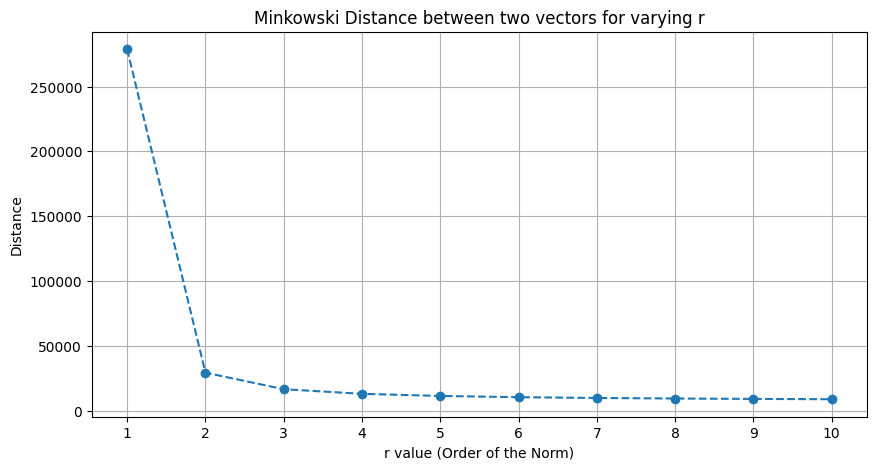


--- A4: Splitting data into training and testing sets ---
Data split into 191 training samples and 83 testing samples.

--- A5: Training k-NN with k=3 ---
k-NN (k=3) classifier trained successfully.

--- A6: Testing Accuracy for k=3 ---
Accuracy of k-NN (k=3) on the test set: 0.9759

--- A7: Prediction Example ---
Model predictions for first 5 test vectors: [1 1 1 1 0]
Actual labels for first 5 test vectors:   [1 1 1 1 0]

--- A8: Accuracy Plot for k=1 to 11 ---


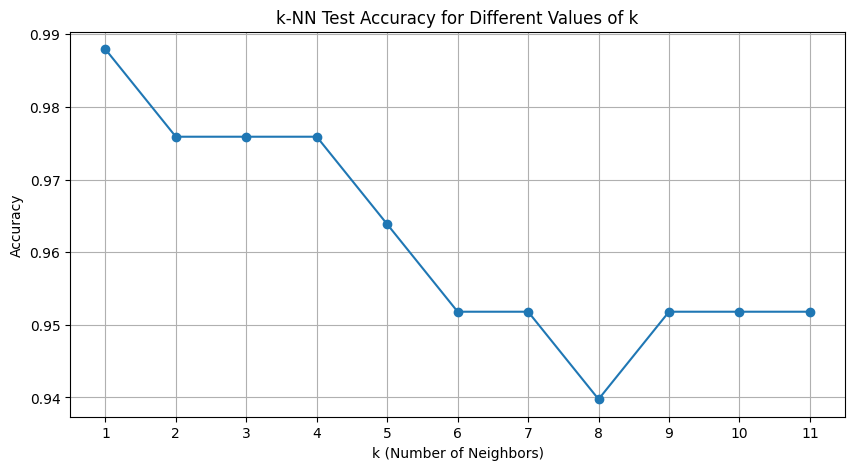


--- A9: Detailed Performance Metrics for k=3 ---
Confusion Matrix (k=3):
        Pred 0 | Pred 1
True 0:    11   |   1
True 1:    1   |   70

Precision: 0.9859
Recall: 0.9859
F1-Score: 0.9859


In [7]:
# --- 4. ASSIGNMENT EXECUTION (A1-A9) ---
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support, roc_curve, auc

# Check if we have data before proceeding
if X.shape[0] == 0:
    print("Execution stopped: No data was loaded in the previous step. Please resolve errors in Cell 3.")
else:
    # --- A1: Intraclass Spread and Interclass Distances ---
    print("\n--- A1: Class Centroids and Spread ---")

    # Separate the feature vectors for each class
    X_rickettsia = X[y == 0]
    X_wolbachia = X[y == 1]

    # Calculate centroids (mean vector for each class)
    centroid_rickettsia = np.mean(X_rickettsia, axis=0)
    centroid_wolbachia = np.mean(X_wolbachia, axis=0)

    # Calculate spread (the average of the standard deviation vector for each class)
    spread_rickettsia = np.mean(np.std(X_rickettsia, axis=0))
    spread_wolbachia = np.mean(np.std(X_wolbachia, axis=0))

    # Calculate distance between centroids
    inter_class_distance = np.linalg.norm(centroid_rickettsia - centroid_wolbachia)

    print(f"Average Spread (Intra-class) for Rickettsia (Class 0): {spread_rickettsia:.4f}")
    print(f"Average Spread (Intra-class) for Wolbachia (Class 1): {spread_wolbachia:.4f}")
    print(f"Distance between Centroids (Inter-class distance): {inter_class_distance:.4f}")

    # --- A2: Feature Density Histogram ---
    print("\n--- A2: Feature Histogram ---")
    # Let's take a feature index to plot. You can change this number.
    feature_index_to_plot = 15
    feature_name = get_kmer_features(K_VALUE)[feature_index_to_plot]

    plt.figure(figsize=(12, 6))
    plt.hist(X_rickettsia[:, feature_index_to_plot], bins=30, alpha=0.7, label='Rickettsia (Class 0)')
    plt.hist(X_wolbachia[:, feature_index_to_plot], bins=30, alpha=0.7, label='Wolbachia (Class 1)')
    plt.title(f"Histogram for feature: '{feature_name}' k-mer count")
    plt.xlabel("k-mer Count")
    plt.ylabel("Frequency of Sequences")
    plt.legend()
    plt.grid(axis='y', alpha=0.5)
    plt.show()

    # --- A3: Minkowski Distance ---
    print("\n--- A3: Minkowski Distance Plot ---")
    # Take two vectors from different classes
    vec1 = X_rickettsia[0]
    vec2 = X_wolbachia[0]
    r_values = range(1, 11)
    minkowski_distances = [np.linalg.norm(vec1 - vec2, ord=r) for r in r_values]

    plt.figure(figsize=(10, 5))
    plt.plot(r_values, minkowski_distances, marker='o', linestyle='--')
    plt.title("Minkowski Distance between two vectors for varying r")
    plt.xlabel("r value (Order of the Norm)")
    plt.ylabel("Distance")
    plt.xticks(r_values)
    plt.grid(True)
    plt.show()

    # --- A4: Train-Test Split ---
    print("\n--- A4: Splitting data into training and testing sets ---")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    print(f"Data split into {X_train.shape[0]} training samples and {X_test.shape[0]} testing samples.")

    # --- A5: Train a k-NN Classifier ---
    print("\n--- A5: Training k-NN with k=3 ---")
    knn_k3 = KNeighborsClassifier(n_neighbors=3)
    knn_k3.fit(X_train, y_train)
    print("k-NN (k=3) classifier trained successfully.")

    # --- A6: Test the Accuracy ---
    print("\n--- A6: Testing Accuracy for k=3 ---")
    accuracy_k3 = knn_k3.score(X_test, y_test)
    print(f"Accuracy of k-NN (k=3) on the test set: {accuracy_k3:.4f}")

    # --- A7: Prediction Behavior ---
    print("\n--- A7: Prediction Example ---")
    # Let's take the first 5 vectors from the test set
    test_sample = X_test[:5]
    sample_predictions = knn_k3.predict(test_sample)
    print(f"Model predictions for first 5 test vectors: {sample_predictions}")
    print(f"Actual labels for first 5 test vectors:   {y_test[:5]}")

    # --- A8: Varying k ---
    print("\n--- A8: Accuracy Plot for k=1 to 11 ---")
    k_values = range(1, 12)
    k_accuracies = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        acc = knn.score(X_test, y_test)
        k_accuracies.append(acc)

    plt.figure(figsize=(10, 5))
    plt.plot(k_values, k_accuracies, marker='o')
    plt.title("k-NN Test Accuracy for Different Values of k")
    plt.xlabel("k (Number of Neighbors)")
    plt.ylabel("Accuracy")
    plt.xticks(k_values)
    plt.grid(True)
    plt.show()

    # --- A9: Confusion Matrix and Other Metrics ---
    print("\n--- A9: Detailed Performance Metrics for k=3 ---")
    y_pred_k3 = knn_k3.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_k3)

    # Note: 'average="binary"' assumes Class 1 is the "positive" class
    precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred_k3, average='binary')

    print("Confusion Matrix (k=3):")
    print("        Pred 0 | Pred 1")
    print(f"True 0:    {cm[0,0]}   |   {cm[0,1]}")
    print(f"True 1:    {cm[1,0]}   |   {cm[1,1]}")

    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1_score:.4f}")



--- O1: Normal Distribution Comparison ---


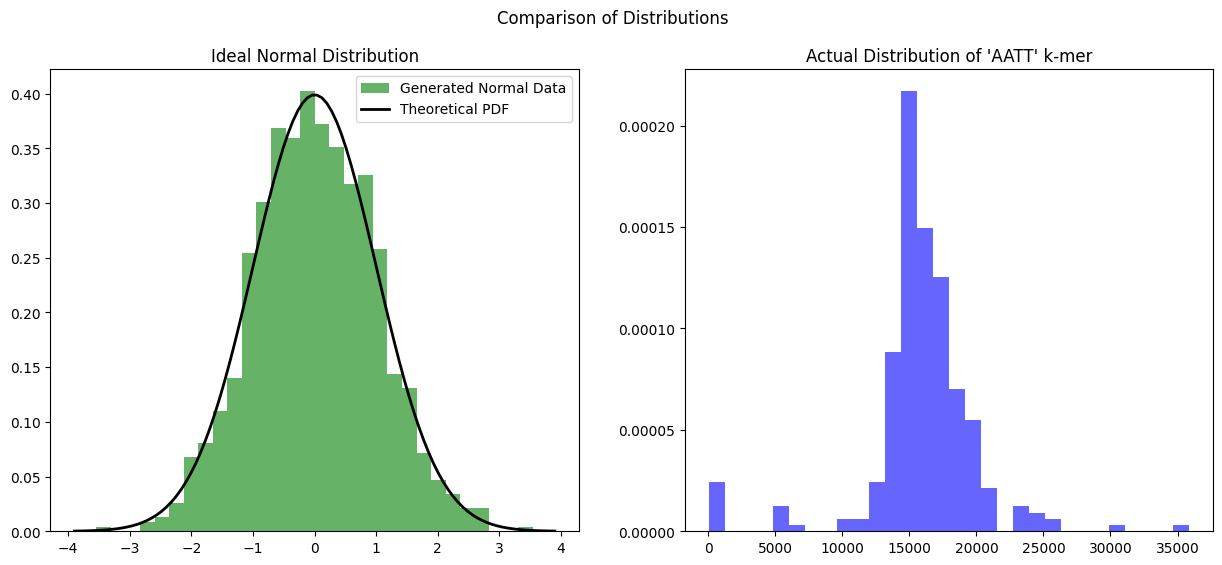

Observation: The plot on the left shows a perfect 'bell curve'. The plot on the right, from our actual data, is not normally distributed. This is common for count-based data.

--- O2: Comparing k-NN with Different Distance Metrics (k=3) ---
Accuracy results:
- Metric: euclidean  | Test Accuracy: 0.9759
- Metric: manhattan  | Test Accuracy: 0.9759
- Metric: chebyshev  | Test Accuracy: 0.9639

Observation: Different distance metrics can yield different accuracies. 'Euclidean' is often a good default, but for high-dimensional data like ours, 'manhattan' can sometimes be more robust.

--- O3: AUROC Plot for k-NN Classifier (k=3) ---


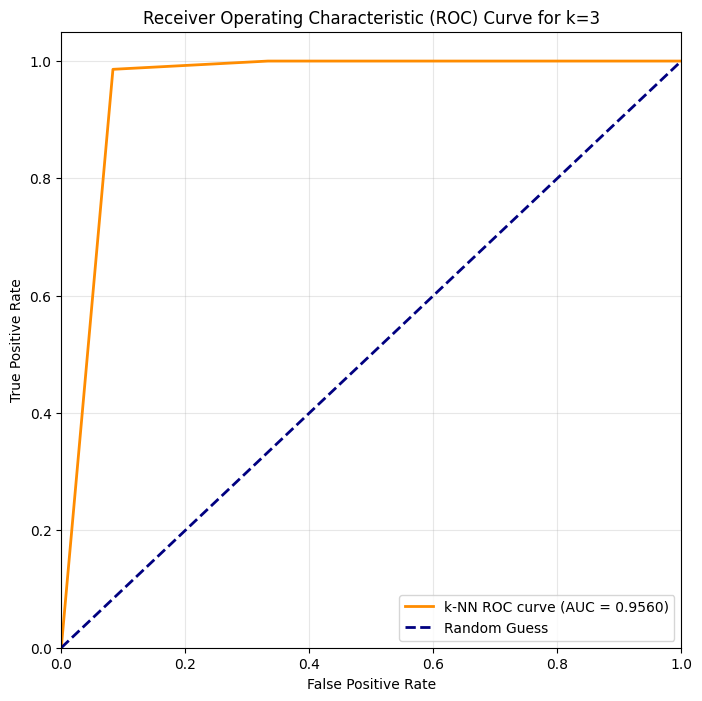

Inference: The Area Under the Curve (AUC) is 0.9560. An AUC of 0.5 represents a random guess, and an AUC of 1.0 represents a perfect classifier. Our score indicates that the model has significant predictive power.

--- O4: Comparing Scikit-learn k-NN with your custom model ---
To complete this step, you would need to run your custom k-NN model from Lab 2 on the same data.

Scikit-learn k-NN Accuracy: 0.9759
Your Custom k-NN Accuracy: [Enter your model's accuracy here after you calculate it]

Comparison: This allows you to validate your own implementation. A professional library like scikit-learn is highly optimized and should generally perform as well or better than a from-scratch implementation.


In [8]:
# --- 5. OPTIONAL SECTION (O1-O4) ---
# This cell assumes the previous cells have been run successfully.

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm # Needed for O1
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc

# Check if we have data before proceeding
if 'X' not in locals() or X.shape[0] == 0:
    print("Execution stopped: Please run the data processing and model training cells first.")
else:
    # --- O1: Normal Distribution Comparison ---
    print("\n--- O1: Normal Distribution Comparison ---")

    # Part 1: Create and plot a perfect normal distribution
    mu, sigma = 0, 1 # Mean and standard deviation
    s = np.random.normal(mu, sigma, 1000) # Generate 1000 random samples

    plt.figure(figsize=(15, 6))

    # Plot the ideal normal distribution
    ax1 = plt.subplot(1, 2, 1)
    ax1.hist(s, bins=30, density=True, alpha=0.6, color='g', label='Generated Normal Data')
    # Plot the theoretical probability density function (PDF)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, sigma)
    ax1.plot(x, p, 'k', linewidth=2, label='Theoretical PDF')
    ax1.set_title("Ideal Normal Distribution")
    ax1.legend()

    # Part 2: Compare against one of our actual feature histograms (from A2)
    ax2 = plt.subplot(1, 2, 2)
    feature_index_to_plot = 15
    feature_name = get_kmer_features(K_VALUE)[feature_index_to_plot]
    ax2.hist(X[:, feature_index_to_plot], bins=30, density=True, alpha=0.6, color='b')
    ax2.set_title(f"Actual Distribution of '{feature_name}' k-mer")

    plt.suptitle("Comparison of Distributions")
    plt.show()

    print("Observation: The plot on the left shows a perfect 'bell curve'. The plot on the right, from our actual data, is not normally distributed. This is common for count-based data.")

    # --- O2: Using Different Distance Metrics for k-NN ---
    print("\n--- O2: Comparing k-NN with Different Distance Metrics (k=3) ---")

    metrics_to_test = ['euclidean', 'manhattan', 'chebyshev']
    results = {}

    for metric_name in metrics_to_test:
        # Create, train, and test a new k-NN classifier with the specified metric
        knn = KNeighborsClassifier(n_neighbors=3, metric=metric_name)
        knn.fit(X_train, y_train)
        accuracy = knn.score(X_test, y_test)
        results[metric_name] = accuracy

    print("Accuracy results:")
    for metric_name, accuracy in results.items():
        print(f"- Metric: {metric_name:<10} | Test Accuracy: {accuracy:.4f}")

    print("\nObservation: Different distance metrics can yield different accuracies. 'Euclidean' is often a good default, but for high-dimensional data like ours, 'manhattan' can sometimes be more robust.")

    # --- O3: Make an AUROC Plot ---
    # Note: This was already done in the previous cell, but we include it here
    # again for completeness as requested by the assignment.
    print("\n--- O3: AUROC Plot for k-NN Classifier (k=3) ---")

    # Get prediction probabilities for the positive class (Wolbachia, Class 1)
    y_scores = knn_k3.predict_proba(X_test)[:, 1]

    # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'k-NN ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve for k=3')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    print(f"Inference: The Area Under the Curve (AUC) is {roc_auc:.4f}. An AUC of 0.5 represents a random guess, and an AUC of 1.0 represents a perfect classifier. Our score indicates that the model has significant predictive power.")

    # --- O4: Compare with your custom k-NN model ---
    print("\n--- O4: Comparing Scikit-learn k-NN with your custom model ---")
    print("To complete this step, you would need to run your custom k-NN model from Lab 2 on the same data.")

    # Step 1: Get the accuracy of the scikit-learn model (which we already have)
    sklearn_accuracy = accuracy_score(y_test, knn_k3.predict(X_test))

    # Step 2: You would run your custom model's predict function
    # EXAMPLE: custom_predictions = my_custom_knn_predict(X_train, y_train, X_test, k=3)

    # Step 3: You would then calculate its accuracy
    # EXAMPLE: custom_accuracy = np.sum(custom_predictions == y_test) / len(y_test)

    # Step 4: Compare them
    print(f"\nScikit-learn k-NN Accuracy: {sklearn_accuracy:.4f}")
    print("Your Custom k-NN Accuracy: [Enter your model's accuracy here after you calculate it]")
    print("\nComparison: This allows you to validate your own implementation. A professional library like scikit-learn is highly optimized and should generally perform as well or better than a from-scratch implementation.")